In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error

from external.pykernels.pykernels.basic import Linear, RBF, Polynomial

Note: I do not comment on every single variable I am introducing but just on key steps because I am a proponent of "speaking variables" meaning that the variables should in principle be named in a way that one knows what they do. I hope therefore the code is self-containedly understandable.

# **Coursework Assignment 1**

Defining the simple 1D target functions...

In [ ]:
def sin_function(x):
    return np.sin(2*x+3)-1

def polynome2_function(x):
    return 3*x**2 + 4*x - 5

def polynome4_function(x):
    return x**4 - 0.5*x**3 + x -1

def exp_function(x):
    return 0.1*np.exp(-0.5*x)


Defining the noise that is being added to the functions. Noise_index is a parameter that influences how much noise (in relation to the variance of the function values) is being added. This parameter is not further investigated in this project and usually set to 0.05.

In [ ]:
rng = np.random.default_rng(42)

# if noise_index was 1 then same magnitude of noise as signal - regression difficult
def gaussian_noise(y_values, noise_index, rng=None):
    std_noise = noise_index * np.std(y_values)
    gaussian_noise = rng.normal(0, std_noise, len(y_values))
    return gaussian_noise, std_noise

In [ ]:
class GPR_regressor:
    """
    Simple Gaussian Process Regression model using a user-defined kernel.
    """

    def __init__(self, kernel=RBF()):
        self.c = None
        self.x_train = None
        self.kernel = kernel

    def _ensure_2d(self, X):
        """
        Ensures input is shaped as (N, 1), which is required
        for consistent kernel computations and usage of the external package.
        """
        X = np.asarray(X)
        if X.ndim == 0:
            X = X.reshape(1, 1)
        elif X.ndim == 1:
            X = X.reshape(-1, 1)
        return X

    def fit(self, x_train, y_train):
        """
        Fit model assuming default noise level of 0.1.
        """
        self.fit_known_noise_std(x_train, y_train, 0.1)

    def fit_known_noise_std(self, x_train, y_train, noise_std):
        """
        Standard GPR training step:
        computes coefficients c = (K + sigma**2*I)^(-1) y
        """
        x_train = self._ensure_2d(x_train)       
        dim = len(x_train)
        KNN = self.kernel(x_train, x_train)
        to_invert = KNN + noise_std**2 * np.identity(dim)
        self.c = np.linalg.solve(to_invert, y_train)
        self.x_train = x_train

    def predict(self, x_test):
        """
        Predict using kernel expansion:
        y(x) = sum_i c_i k(x_i, x)
        """
        x_test = self._ensure_2d(x_test)
        if self.c is not None:
            kernel_distances = self.kernel(self.x_train, x_test)
            y_pred = np.dot(self.c, kernel_distances)
            return y_pred
        else:
            print("The model has not been trained before trying to predict!")
            return None

    def evaluate(self, x_test, y_true, metric=root_mean_squared_error, verbose=False):
        """
        Evaluate model performance using a given metric (default: RMSE).
        """
        # estimate a metric on the given set
        y_pred = self.predict(x_test)
        if y_pred is None:
            raise ValueError("Prediction cannot be None. Is the model trained?")
        met = metric(y_true, y_pred)

        if verbose:
            print(f"Achieved {met}")
        return met

Some utility functions: create a noised set of y values depending on given x values and calculating the parameter gamma from the length scale for the RBF function

In [ ]:
def create_noised_train_set(function_to_approximate, x_train, noise_index=0.1, lower_boundary=-5, upper_boundary=5, rng = rng):
    y_without_noise = function_to_approximate(x_train)
    gaussian_noise_, noise_std = gaussian_noise(y_without_noise, noise_index, rng)
    y_train = y_without_noise + gaussian_noise_

    return y_train, noise_std

def gamma_from_length_scale(length_scale):
    return 1/(2*length_scale**2)

Creating a model from scratch, given a string indicating which function out of the ones defined above to use and which basis functions to use.

In [ ]:
def create_regressor(x_train, function_to_investigate_string, basis_functions_string, length_scale=0.5, polynomial_degree=3, noise_index=0.1):
    gamma = gamma_from_length_scale(length_scale)

    function_to_investigate = sin_function
    if function_to_investigate_string == 'polynome2':
        function_to_investigate = polynome2_function
    elif function_to_investigate_string == 'polynome4':
        function_to_investigate = polynome4_function
    elif function_to_investigate_string == 'exp':
        function_to_investigate = exp_function


    basis_functions = Linear()
    basis_functions_verbose = 'Linear'
    if basis_functions_string == 'Polynomial':
        basis_functions = Polynomial(polynomial_degree)
        basis_functions_verbose = f'Polynomial_{polynomial_degree}'
    elif basis_functions_string == 'RBF':
        basis_functions = RBF(gamma)
        basis_functions_verbose = f'RBF_{length_scale}'

    y_train, noise_std_train = create_noised_train_set(function_to_investigate, x_train, noise_index, lower_boundary, upper_boundary)
    regressor = GPR_regressor(basis_functions)
    regressor.fit(x_train, y_train)
    return regressor, function_to_investigate, basis_functions_verbose


In [ ]:
number_of_training_samples = 20
noise_index = 0.05

lower_boundary = -5
upper_boundary = 5

Run, plot and save the plots of the GPR for various combinations of basis functions and target function ("funciton to investigate") - and, in the case of the RBF kernel, also loop over different length scales to later do a little hyperparameter comparison

In [ ]:
from sklearn.metrics import root_mean_squared_error

functions = ['sin', 'polynome2', 'polynome4', 'exp']
basis_functions = ['RBF', 'Linear', 'Polynomial']
length_scales = [0.001, 0.1, 0.5, 1, 10, 100]
polynomial_degree = 4

rsme_output = ""


x_test = rng.uniform(lower_boundary, upper_boundary, size=100)
x_train = rng.uniform(lower_boundary, upper_boundary, size=number_of_training_samples)


rsme_length_scales = np.zeros((len(functions), len(length_scales)))


print(length_scales)

for i, function_to_investigate_string in enumerate(functions):
    for basis_function_string in basis_functions:

        if basis_function_string == "RBF":
            length_scales_to_test =  length_scales

        else:
            length_scales_to_test = [0.5] # this number does not matter in that case

        for j, current_length_scale in enumerate(length_scales_to_test):
            regressor, function_to_investigate, basis_functions_verbose = create_regressor(x_train, function_to_investigate_string, basis_function_string, current_length_scale, polynomial_degree, noise_index)
    
            y_test = function_to_investigate(x_test)
            y_test_predicted = regressor.predict(x_test)
            rmse = root_mean_squared_error(y_test, y_test_predicted) / np.std(y_test)
            if basis_function_string == "RBF":
                rsme_output += f"Function {function_to_investigate_string} with basis functions {basis_function_string} and length scale {current_length_scale} achieved RSME {rmse}\n"
                rsme_length_scales[i][j] = rmse
            else:
                rsme_output += f"Function {function_to_investigate_string} with basis functions {basis_function_string} achieved RSME {rmse}\n"

            x_all = np.linspace(lower_boundary-0.5, upper_boundary+0.5, 1000)
            y_all_true = function_to_investigate(x_all)
            y_all_predicted = regressor.predict(x_all)
            y_train = function_to_investigate(x_train)

            plt.plot(x_all, y_all_true, label = "true")
            plt.plot(x_all, y_all_predicted, label = "predicted")
            plt.scatter(x_train, y_train)
            plt.xlabel("x")
            plt.ylabel(r"y")
            plt.legend()
            filename = f"plots/Task_1_second_version_{basis_functions_verbose}_n_{number_of_training_samples}_{function_to_investigate_string}_noise_{noise_index}.png"
            if basis_function_string == "RBF":
                filename = f"plots/Task_1_second_version_{basis_functions_verbose}_length_scale_{current_length_scale}_n_{number_of_training_samples}_{function_to_investigate_string}_noise_{noise_index}.png"
            plt.savefig(filename, dpi=300, bbox_inches="tight")
            plt.close()

[0.001, 0.1, 0.5, 1, 10, 100]
Function sin with basis functions RBF and length scale 0.001 achieved RSME 1.7143716366375854
Function sin with basis functions RBF and length scale 0.1 achieved RSME 1.178646182792449
Function sin with basis functions RBF and length scale 0.5 achieved RSME 0.22948488895180139
Function sin with basis functions RBF and length scale 1 achieved RSME 0.07249897992324401
Function sin with basis functions RBF and length scale 10 achieved RSME 0.9606043255866666
Function sin with basis functions RBF and length scale 100 achieved RSME 0.9617957970479337
Function sin with basis functions Linear achieved RSME 1.7061266317021546
Function sin with basis functions Polynomial achieved RSME 1.357601030199124
Function polynome2 with basis functions RBF and length scale 0.001 achieved RSME 1.3051183396933308
Function polynome2 with basis functions RBF and length scale 0.1 achieved RSME 0.807439804128356
Function polynome2 with basis functions RBF and length scale 0.5 achie

Plot the RMSE of the GPR dependent on the length scale used for the RBF kernel and the target function (different curves).

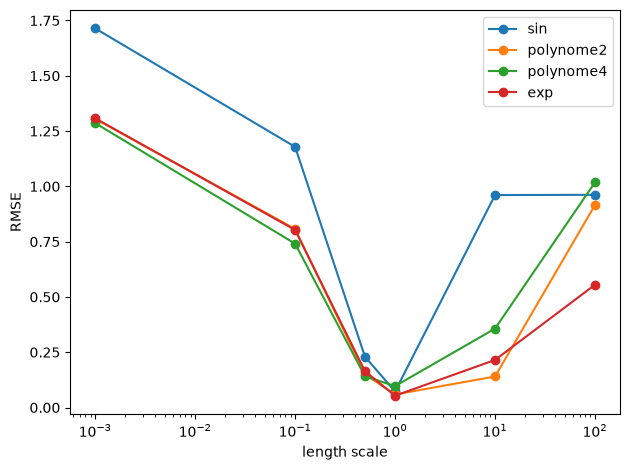

In [ ]:
plt.figure()

for i in range(rsme_length_scales.shape[0]):
    plt.plot(length_scales, rsme_length_scales[i], marker="o", label=f"{functions[i]}")

plt.xlabel("length scale")
plt.xscale("log")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.savefig("plots/rsme_over_length_scale", dpi = 300)
plt.show()

**Question 1b)**

Defining the RBF kernel with derivatives. X denotes data locations for function values, Z for derivative values.

In [13]:
import numpy as np


class RBFWithDerivatives1D:
    def __init__(self, length_scale=1.0, variance=1.0):
        self.length_scale = length_scale
        self.variance = variance

    def k(self, X, Y):
        r = X - Y.T
        ell2 = self.length_scale ** 2

        return self.variance * np.exp(-0.5 * r**2 / ell2)

    def k_f_d(self, X, Z):
        """
        Cov(f(X), f'(Z))
        """

        K = self.k(X, Z)
        r = X - Z.T
        ell2 = self.length_scale ** 2

        return K * r / ell2

    def k_d_f(self, Z, X):
        """
        Cov(f'(Z), f(X))
        """

        K = self.k(Z, X)
        r = Z - X.T
        ell2 = self.length_scale ** 2

        return -K * r / ell2

    def k_d_d(self, Z1, Z2):
        """
        Cov(f'(Z1), f'(Z2))
        """

        K = self.k(Z1, Z2)
        r = Z1 - Z2.T
        ell = self.length_scale

        return K * (1 / ell**2 - r**2 / ell**4)

In [ ]:
class GPRWithDerivativeObservations1D:
    def __init__(self, kernel=None):
        self.kernel = kernel if kernel is not None else RBFWithDerivatives1D()
        self.c = None
        self.X_value = None
        self.X_deriv = None

    def _ensure_2d(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim == 0:
            X = X.reshape(1, 1)
        elif X.ndim == 1:
            X = X.reshape(-1, 1)
        return X

    def fit(self, X_value=None, y_value=None, X_deriv=None, y_deriv=None, noise_value_std=1e-6, noise_deriv_std=1e-6):
        y_all = []
        print(type(y_value))

        has_values = X_value is not None and y_value is not None
        has_derivs = X_deriv is not None and y_deriv is not None

        # different cases dependent on which data is given - just derivative values ("derivs"), just function values ("values") or both
        if has_values:
            X_value = self._ensure_2d(X_value)
            y_value = np.asarray(y_value, dtype=float).ravel()
            y_all.append(y_value)

        if has_derivs:
            X_deriv = self._ensure_2d(X_deriv)
            y_all.append(y_deriv)

        if has_values and has_derivs:
            K_ff = self.kernel.k(X_value, X_value)
            K_fd = self.kernel.k_f_d(X_value, X_deriv)
            K_df = self.kernel.k_d_f(X_deriv, X_value)
            K_dd = self.kernel.k_d_d(X_deriv, X_deriv)

            K = np.block([ # the mentioned Covariance matrix between derivative and function values
                [K_ff, K_fd],
                [K_df, K_dd]
            ])

            gross_sigma = np.concatenate([
                noise_value_std**2 * np.ones(len(X_value)),
                noise_deriv_std**2 * np.ones(len(X_deriv))
            ])

        elif has_values:
            K = self.kernel.k(X_value, X_value)
            gross_sigma = noise_value_std**2 * np.ones(len(X_value))

        else:
            K = self.kernel.k_d_d(X_deriv, X_deriv)
            gross_sigma = noise_deriv_std**2 * np.ones(len(X_deriv))

        y_obs = np.concatenate(y_all)

        # this is the matrix to invert
        K_noisy = K + np.diag(gross_sigma)

        self.c = np.linalg.solve(K_noisy, y_obs)
        self.X_value = X_value if has_values else None
        self.X_deriv = X_deriv if has_derivs else None

    def predict(self, X_test):
        X_test = self._ensure_2d(X_test)

        if self.c is None:
            raise ValueError("Model has not been fitted.")

        k_parts = []

        if self.X_value is not None:
            k_parts.append(self.kernel.k(self.X_value, X_test))

        if self.X_deriv is not None:
            # Cov(f'(z), f(x_*)) # here we must also calculate the covariance matrix between a derivative value and function value - therefore we use k_d_f
            k_parts.append(self.kernel.k_d_f(self.X_deriv, X_test))

        K_obs_test = np.vstack(k_parts)

        return K_obs_test.T @ self.c

In [15]:
def derivative_of_sin_function(x):
    return 2*np.cos(2*x+3)

The following last three cells just do some plotting and repeat themselves apart from the line split_idx = int(0.6 * len(x_train))
(I should therefore have put this in its own function, I am just now noticing...)

<class 'numpy.ndarray'>


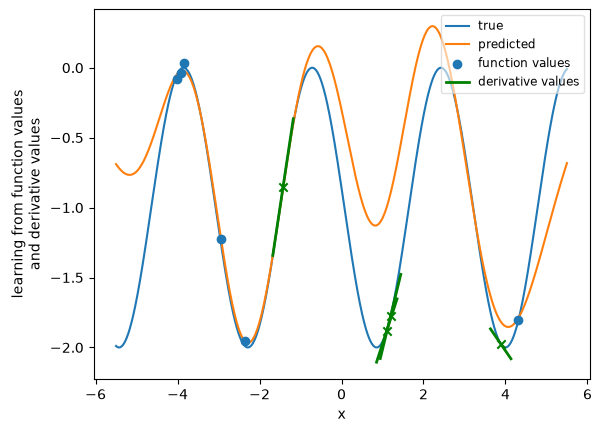

In [ ]:
number_of_training_samples = 10
x_train = rng.uniform(lower_boundary, upper_boundary, size=number_of_training_samples)
noise_index = 0.05

shuffled = rng.permutation(x_train)
split_idx = int(0.6 * len(x_train))

x_train_values = shuffled[:split_idx]
x_train_deriv = shuffled[split_idx:]

y_train_values, _ = create_noised_train_set(sin_function, x_train_values, noise_index=noise_index)
y_train_deriv, _ = create_noised_train_set(derivative_of_sin_function, x_train_deriv, noise_index=noise_index)

kernel = RBFWithDerivatives1D(length_scale=1.0, variance=1.0)

model = GPRWithDerivativeObservations1D(kernel=kernel)

model.fit(X_value=x_train_values, y_value=y_train_values, X_deriv=x_train_deriv, y_deriv=y_train_deriv, noise_value_std=0.05, noise_deriv_std=0.05)

y_train_deriv_y_values = sin_function(x_train_deriv)
x_all = np.linspace(lower_boundary-0.5, upper_boundary+0.5, 1000)
y_all_true = sin_function(x_all)
y_all_predicted = model.predict(x_all)


plt.plot(x_all, y_all_true, label="true")
plt.plot(x_all, y_all_predicted, label="predicted")

# scattering normal train values
plt.scatter(
    x_train_values,
    y_train_values,
    label="function values",
    zorder=3
)

tangent_width = 0.25

for x_d, y_d_loc, slope in zip(x_train_deriv, y_train_deriv_y_values, y_train_deriv):
    x_tangent = np.array([x_d - tangent_width, x_d + tangent_width])
    y_tangent = y_d_loc + slope * (x_tangent - x_d)

    plt.plot(
        x_tangent,
        y_tangent,
        linewidth=2,
        color="green",
        label="derivative values" if x_d == x_train_deriv[0] else None
    )

    plt.scatter(x_d, y_d_loc, marker="x", zorder=4, color="green")

plt.xlabel("x")
plt.ylabel("learning from function values\nand derivative values")
plt.legend(
    loc="upper right",
    fontsize="small",
    framealpha=0.6
)
filename = (
    f"plots/Task_1b_mixture_second_version_n_{number_of_training_samples}.png"
)

plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()

/home/jetti/programs/miniconda3/envs/mlmc/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/jetti/programs/miniconda3/envs/mlmc/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/jetti/programs/miniconda3/envs/mlmc/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


<class 'numpy.ndarray'>


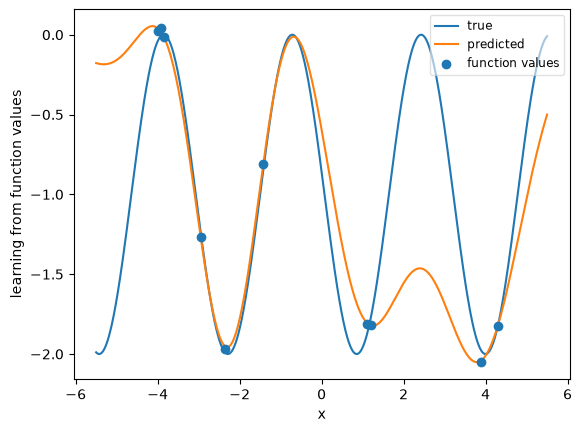

In [ ]:
shuffled = rng.permutation(x_train)
split_idx = int(1 * len(x_train)) # more complicated way of saying - only function values (because the code was lying around already...)

x_train_values = shuffled[:split_idx]
x_train_deriv = shuffled[split_idx:]

y_train_values, _ = create_noised_train_set(sin_function, x_train_values, noise_index=noise_index)
y_train_deriv, _ = create_noised_train_set(derivative_of_sin_function, x_train_deriv, noise_index=noise_index)

kernel = RBFWithDerivatives1D(length_scale=1.0, variance=1.0)

model = GPRWithDerivativeObservations1D(kernel=kernel)

model.fit(X_value=x_train_values, y_value=y_train_values, X_deriv=x_train_deriv, y_deriv=y_train_deriv, noise_value_std=0.05, noise_deriv_std=0.05)

y_train_deriv_y_values = sin_function(x_train_deriv)
x_all = np.linspace(lower_boundary-0.5, upper_boundary+0.5, 1000)
y_all_true = sin_function(x_all)
y_all_predicted = model.predict(x_all)


plt.plot(x_all, y_all_true, label="true")
plt.plot(x_all, y_all_predicted, label="predicted")

plt.scatter(
    x_train_values,
    y_train_values,
    label="function values",
    zorder=3
)

tangent_width = 0.25

for x_d, y_d_loc, slope in zip(x_train_deriv, y_train_deriv_y_values, y_train_deriv):
    x_tangent = np.array([x_d - tangent_width, x_d + tangent_width])
    y_tangent = y_d_loc + slope * (x_tangent - x_d)

    plt.plot(
        x_tangent,
        y_tangent,
        linewidth=2,
        color="green",
        label="derivative values" if x_d == x_train_deriv[0] else None
    )

    plt.scatter(x_d, y_d_loc, marker="x", zorder=4, color="green")

plt.xlabel("x")
plt.ylabel(r"learning from function values")
plt.legend(
    loc="upper right",
    fontsize="small",
    framealpha=0.6
)
filename = (
    f"plots/Task_1b_only_values_second_version_n_{number_of_training_samples}.png"
)

plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()

<class 'numpy.ndarray'>


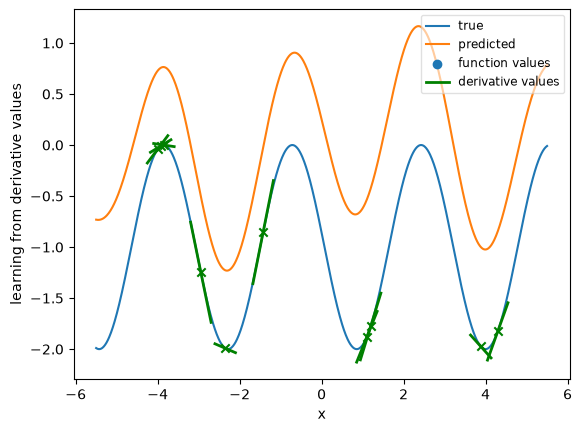

In [ ]:
shuffled = rng.permutation(x_train)
split_idx = int(0 * len(x_train))  # more complicated way of saying - only derivative values (because the code was lying around already...)

x_train_values = shuffled[:split_idx]
x_train_deriv = shuffled[split_idx:]

y_train_values, _ = create_noised_train_set(sin_function, x_train_values, noise_index=noise_index)
y_train_deriv, _ = create_noised_train_set(derivative_of_sin_function, x_train_deriv, noise_index=noise_index)

kernel = RBFWithDerivatives1D(length_scale=1.0, variance=1.0)

model = GPRWithDerivativeObservations1D(kernel=kernel)

model.fit(X_value=x_train_values, y_value=y_train_values, X_deriv=x_train_deriv, y_deriv=y_train_deriv, noise_value_std=0.05, noise_deriv_std=0.05)

y_train_deriv_y_values = sin_function(x_train_deriv)
x_all = np.linspace(lower_boundary-0.5, upper_boundary+0.5, 1000)
y_all_true = sin_function(x_all)
y_all_predicted = model.predict(x_all)


plt.plot(x_all, y_all_true, label="true")
plt.plot(x_all, y_all_predicted, label="predicted")

plt.scatter(
    x_train_values,
    y_train_values,
    label="function values",
    zorder=3
)

tangent_width = 0.25

for x_d, y_d_loc, slope in zip(x_train_deriv, y_train_deriv_y_values, y_train_deriv):
    x_tangent = np.array([x_d - tangent_width, x_d + tangent_width])
    y_tangent = y_d_loc + slope * (x_tangent - x_d)

    plt.plot(
        x_tangent,
        y_tangent,
        linewidth=2,
        color="green",
        label="derivative values" if x_d == x_train_deriv[0] else None
    )

    plt.scatter(x_d, y_d_loc, marker="x", zorder=4, color="green")

plt.xlabel("x")
plt.ylabel(r"learning from derivative values")
plt.legend(
    loc="upper right",
    fontsize="small",
    framealpha=0.6
)
filename = (
    f"plots/Task_1b_only_derivative_second_version_n_{number_of_training_samples}.png"
)

plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()